# 3D LQG Model with u and {hat}x perturbations

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from model import lqg_model

%matplotlib inline

## Initialize 3D LQG Model with Parameters

In [2]:
# define horizon (number of time steps)
horizon = 1000

# target: [px, vx, py, vy, pz, vz]
T_px, T_py, T_pz = 100, 100, 100
T_vx, T_vy, T_vz = 0, 0, 0

# instantiate LQG model
lqg_baseline = lqg_model.LQG(horizon, target=[T_px, T_vx, T_py, T_vy, T_pz, T_vz])

# initial state: [px, vx, py, vy, pz, vz]
x0 = np.matrix([[0],
                [0],
                [0],
                [0],
                [0],
                [0]])

dt = 0.01  # time step in seconds (10 ms per step)

# A: 6x6 state transition matrix 
A = np.matrix([[1, dt, 0,  0, 0,  0],
               [0,  1, 0,  0, 0,  0],
               [0,  0, 1, dt, 0,  0],
               [0,  0, 0,  1, 0,  0],
               [0,  0, 0,  0, 1, dt],
               [0,  0, 0,  0, 0,  1]])

# B: 6x3 control input matrix (ax, ay, az)
B = np.matrix([[0,  0, 0],
               [dt, 0, 0],
               [0,  0, 0],
               [0, dt, 0],
               [0,  0, 0],
               [0,  0, dt]])

# C: 6x6 observation matrix (observe all states)
C = np.matrix(np.eye(6))

# Q: 6x6 state cost — high penalty on position error, low on velocity
Q = np.matrix(np.diag([500, 1, 500, 1, 500, 1]))

# R: 3x3 control cost
R = np.matrix([[0.0001, 0, 0],
               [0, 0.0001, 0],
               [0, 0, 0.0001]])

# V: 6x6 process noise covariance
V = np.matrix(0.001 * np.eye(6))

# W: 6x6 measurement noise covariance
W = np.matrix(1.5 * np.eye(6))

# X0: 6x6 initial state covariance
X0 = np.matrix(0.1 * np.eye(6))

# define model parameters
lqg_baseline.define('A', A)
lqg_baseline.define('B', B)
lqg_baseline.define('C', C)
lqg_baseline.define('Q', Q)
lqg_baseline.define('R', R)
lqg_baseline.define('V', V)
lqg_baseline.define('W', W)
lqg_baseline.define('X', X0)

print("3D LQG model:")
print(f"\tHorizon: {horizon} time steps, dt={dt}s")
print(f"\tState: [px, vx, py, vy, pz, vz]")
print(f"\tControl: [ax, ay, az]")
print(f"\tTarget: px={T_px}, py={T_py}, pz={T_pz}")

3D LQG model:
	Horizon: 1000 time steps, dt=0.01s
	State: [px, vx, py, vy, pz, vz]
	Control: [ax, ay, az]
	Target: px=100, py=100, pz=100


## Baseline Stimulation

In [3]:
np.random.seed(42)

# 6D noise
v_noise = [np.random.randn(6, 1) for _ in range(horizon)]  # process noise
w_noise = [np.random.randn(6, 1) for _ in range(horizon)]  # measurement noise

# initialize true state and state estimate lists
x_baseline_list = [x0.copy()]  # true state
xhat_baseline_list = [x0.copy()]  # state estimate (starts at x0)
u_baseline_list = []

target = np.matrix([[T_px], [T_vx], [T_py], [T_vy], [T_pz], [T_vz]])

# control gains
lqg_baseline.kalman()  # Kalman gains
lqg_baseline.control()  # control gains

# simulate with control
for t in range(horizon - 1):
    # controller: compute control based on state estimate
    u_t = lqg_baseline.var['K'][t] * (xhat_baseline_list[t] - target)
    u_baseline_list.append(u_t)

    # true state update
    x_next = A * x_baseline_list[t] + B * u_t + V * np.matrix(v_noise[t])
    x_baseline_list.append(x_next)

    # observation with noise
    y = C * x_next + W * np.matrix(w_noise[t + 1])

    # Kalman filter update
    xhat_pred = A * xhat_baseline_list[t] + B * u_t
    y_tilde = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde
    xhat_baseline_list.append(xhat_next)

# add final control
u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_baseline_list[-1] - target)
u_baseline_list.append(u_final)

# extract positions from 6D state [px, vx, py, vy, pz, vz]
px_baseline    = np.array([x_baseline_list[t][0, 0]    for t in range(horizon)])
py_baseline    = np.array([x_baseline_list[t][2, 0]    for t in range(horizon)])
pz_baseline    = np.array([x_baseline_list[t][4, 0]    for t in range(horizon)])
pxhat_baseline = np.array([xhat_baseline_list[t][0, 0] for t in range(horizon)])
pyhat_baseline = np.array([xhat_baseline_list[t][2, 0] for t in range(horizon)])
pzhat_baseline = np.array([xhat_baseline_list[t][4, 0] for t in range(horizon)])

# store baseline data
baseline_data = {
    'x': x_baseline_list,
    'kf': {'x1': xhat_baseline_list},
    'u': u_baseline_list,
    'noise': {
        'v': [np.matrix(v_noise[t]) for t in range(horizon)],
        'w': [np.matrix(w_noise[t]) for t in range(horizon)]
    },
    'target': target
}

print("baseline simulation summary:")
print(f"\tx final: {px_baseline[-1]:.4f}  (target {T_px})")
print(f"\ty final: {py_baseline[-1]:.4f}  (target {T_py})")
print(f"\tz final: {pz_baseline[-1]:.4f}  (target {T_pz})")
print(f"\tmean |px - pxhat|: {np.mean(np.abs(px_baseline - pxhat_baseline)):.4f}")
print(f"\tmean |py - pyhat|: {np.mean(np.abs(py_baseline - pyhat_baseline)):.4f}")
print(f"\tmean |pz - pzhat|: {np.mean(np.abs(pz_baseline - pzhat_baseline)):.4f}")

baseline simulation summary:
	x final: 99.9985  (target 100)
	y final: 100.0538  (target 100)
	z final: 100.0078  (target 100)
	mean |px - pxhat|: 0.0480
	mean |py - pyhat|: 0.0504
	mean |pz - pzhat|: 0.0755


## Perturb u (all axes)
- inject a pulse (decrease in acceleration) into u for x, y, and z axes simultaneously
- Kalman uses u_actual as efference copy, so x and xhat stay aligned in all axes

In [4]:
np.random.seed(42)

perturbation_start = 200
perturbation_end   = 250

# per-dimension control perturbation magnitudes
# 3D model: three acceleration axes (ax, ay, az)
u_x_magnitude = -100   # ax perturbation
u_y_magnitude = -100   # ay perturbation
u_z_magnitude = -100   # az perturbation

v_noise = baseline_data['noise']['v']
w_noise = baseline_data['noise']['w']
target  = baseline_data['target']

# copy baseline up to perturbation point
x_u_pert_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
xhat_u_pert_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
u_u_pert_list    = [baseline_data['u'][t].copy()        for t in range(perturbation_start)]

# simulate with pulse in u_x, u_y, u_z; Kalman uses u_actual (efference copy)
for t in range(perturbation_start, horizon - 1):
    u_intended = lqg_baseline.var['K'][t] * (xhat_u_pert_list[t] - target)

    u_actual = u_intended.copy()
    if perturbation_start <= t < perturbation_end:
        u_actual[0, 0] += u_x_magnitude  # perturb x-acceleration
        u_actual[1, 0] += u_y_magnitude  # perturb y-acceleration
        u_actual[2, 0] += u_z_magnitude  # perturb z-acceleration

    u_u_pert_list.append(u_actual)

    x_next = A * x_u_pert_list[t] + B * u_actual + V * v_noise[t]
    x_u_pert_list.append(x_next)

    y = C * x_next + W * w_noise[t + 1]

    xhat_pred = A * xhat_u_pert_list[t] + B * u_actual  # efference copy
    y_tilde   = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde
    xhat_u_pert_list.append(xhat_next)

u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_u_pert_list[-1] - target)
u_u_pert_list.append(u_final)

px_u_pert    = np.array([x_u_pert_list[t][0, 0]    for t in range(horizon)])
py_u_pert    = np.array([x_u_pert_list[t][2, 0]    for t in range(horizon)])
pz_u_pert    = np.array([x_u_pert_list[t][4, 0]    for t in range(horizon)])
pxhat_u_pert = np.array([xhat_u_pert_list[t][0, 0] for t in range(horizon)])
pyhat_u_pert = np.array([xhat_u_pert_list[t][2, 0] for t in range(horizon)])
pzhat_u_pert = np.array([xhat_u_pert_list[t][4, 0] for t in range(horizon)])

u_pert_data = {
    'x': x_u_pert_list,
    'kf': {'x1': xhat_u_pert_list},
    'u': u_u_pert_list,
    'noise': baseline_data['noise'],
    'target': target
}

error_x_u = px_u_pert - pxhat_u_pert
error_y_u = py_u_pert - pyhat_u_pert
error_z_u = pz_u_pert - pzhat_u_pert
print("Control (u) Perturbation — per-axis pulse:")
print(f"  perturbation: t={perturbation_start} to t={perturbation_end}, magnitudes: ax={u_x_magnitude}, ay={u_y_magnitude}, az={u_z_magnitude}")
print(f"  mean |px-pxhat|  before/during/after: "
      f"{np.mean(np.abs(error_x_u[:perturbation_start])):.5f} / "
      f"{np.mean(np.abs(error_x_u[perturbation_start:perturbation_end])):.5f} / "
      f"{np.mean(np.abs(error_x_u[perturbation_end:])):.5f}")
print(f"  mean |py-pyhat|  before/during/after: "
      f"{np.mean(np.abs(error_y_u[:perturbation_start])):.5f} / "
      f"{np.mean(np.abs(error_y_u[perturbation_start:perturbation_end])):.5f} / "
      f"{np.mean(np.abs(error_y_u[perturbation_end:])):.5f}")
print(f"  mean |pz-pzhat|  before/during/after: "
      f"{np.mean(np.abs(error_z_u[:perturbation_start])):.5f} / "
      f"{np.mean(np.abs(error_z_u[perturbation_start:perturbation_end])):.5f} / "
      f"{np.mean(np.abs(error_z_u[perturbation_end:])):.5f}")


Control (u) Perturbation — per-axis pulse:
  perturbation: t=200 to t=250, magnitudes: ax=-100, ay=-100, az=-100
  mean |px-pxhat|  before/during/after: 0.04937 / 0.12516 / 0.04252
  mean |py-pyhat|  before/during/after: 0.03365 / 0.03492 / 0.05590
  mean |pz-pzhat|  before/during/after: 0.03778 / 0.05017 / 0.08718


## xhat perturbation (position bias in all axes)

- during the window, a position bias is applied to xhat[px], xhat[py], and xhat[pz] after each Kalman correction
- this models a persistent external bias on the full 3D position estimate (e.g. a visual perturbation)
- the controller uses the biased xhat → applies wrong acceleration in all axes → x and xhat diverge
- when the window ends, the Kalman corrects xhat back toward x via its own dynamics

In [5]:
from scipy.optimize import brentq

xhat_pulse_duration = 50
_xhat_pulse_end = min(perturbation_start + xhat_pulse_duration, horizon)

# calibrate xhat perturbation magnitude to match target |x deviation| at perturbation_end
target_x_dev_mag = abs(px_u_pert[perturbation_end] - px_baseline[perturbation_end])
print(f"Target |px deviation| at t={perturbation_end}: {target_x_dev_mag:.4f}  (from u perturbation)")
print(f"  u perturbation px dev: {px_u_pert[perturbation_end] - px_baseline[perturbation_end]:.4f}")

def _simulate_xhat_pert(offset):
    """run xhat perturbation for a given per-step position bias in all axes; return (px_arr, pxhat_arr)."""

    v_n = baseline_data['noise']['v']
    w_n = baseline_data['noise']['w']
    tgt = baseline_data['target']

    x_list    = [baseline_data['x'][t].copy()          for t in range(perturbation_start + 1)]
    xhat_list = [baseline_data['kf']['x1'][t].copy()   for t in range(perturbation_start + 1)]
    u_list    = [baseline_data['u'][t].copy()          for t in range(perturbation_start)]

    for t in range(perturbation_start, horizon - 1):
        u_t = lqg_baseline.var['K'][t] * (xhat_list[t] - tgt)
        u_list.append(u_t)

        x_next = A * x_list[t] + B * u_t + V * v_n[t]
        x_list.append(x_next)

        y         = C * x_next + W * w_n[t + 1]
        xhat_pred = A * xhat_list[t] + B * u_t
        y_tilde   = y - C * xhat_pred
        xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde

        if perturbation_start <= (t + 1) < _xhat_pulse_end:
            xhat_next[0, 0] += offset  # px bias
            xhat_next[2, 0] += offset  # py bias
            xhat_next[4, 0] += offset  # pz bias

        xhat_list.append(xhat_next)

    u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_list[-1] - tgt)
    u_list.append(u_final)

    px_arr    = np.array([x_list[t][0, 0]    for t in range(horizon)])
    pxhat_arr = np.array([xhat_list[t][0, 0] for t in range(horizon)])
    return px_arr, pxhat_arr

def _deviation_diff(offset):
    """|px dev| at perturbation_end minus target magnitude; zero when calibrated."""
    px_arr, _ = _simulate_xhat_pert(offset)
    dev_mag = abs(px_arr[perturbation_end] - px_baseline[perturbation_end])
    return dev_mag - target_x_dev_mag

# search only negative offsets so xhat is pushed in the same direction as u perturbation
xhat_position_offset = brentq(_deviation_diff, -200.0, -0.001, xtol=1e-6)

# verify calibration results
_px_cal, _pxhat_cal = _simulate_xhat_pert(xhat_position_offset)
_cal_px_dev  = _px_cal[perturbation_end]    - px_baseline[perturbation_end]
_cal_pxh_dev = _pxhat_cal[perturbation_end] - pxhat_baseline[perturbation_end]
_u_pxh_dev   = pxhat_u_pert[perturbation_end] - pxhat_baseline[perturbation_end]

print(f"\nCalibrated xhat_position_offset = {xhat_position_offset:.4f}  (negative: xhat pushed backward)")
print(f"  |px dev| at t={perturbation_end} (u pert):    {abs(px_u_pert[perturbation_end] - px_baseline[perturbation_end]):.4f}")
print(f"  |px dev| at t={perturbation_end} (xhat pert): {abs(_cal_px_dev):.4f}")
print(f"  pxhat dev at t={perturbation_end} (u pert):    {_u_pxh_dev:.4f}")
print(f"  pxhat dev at t={perturbation_end} (xhat pert): {_cal_pxh_dev:.4f}  (same sign: both negative)")

Target |px deviation| at t=250: 11.2758  (from u perturbation)
  u perturbation px dev: -11.2758

Calibrated xhat_position_offset = -78.2521  (negative: xhat pushed backward)
  |px dev| at t=250 (u pert):    11.2758
  |px dev| at t=250 (xhat pert): 11.2758
  pxhat dev at t=250 (u pert):    -11.2758
  pxhat dev at t=250 (xhat pert): -3243.7635  (same sign: both negative)


In [6]:
np.random.seed(42)

# xhat_position_offset and xhat_pulse_duration come from the calibration cell above
# per-dimension xhat bias controls:
#   position: scale factor on calibrated offset (1.0 = full, 0.0 = none)
#   velocity: direct bias added per step during pulse window
xhat_px_scale = 1.0   # x-position scale
xhat_py_scale = 1.0   # y-position scale
xhat_pz_scale = 1.0   # z-position scale
xhat_vx_bias  = 0.0   # x-velocity direct bias
xhat_vy_bias  = 0.0   # y-velocity direct bias
xhat_vz_bias  = 0.0   # z-velocity direct bias
xhat_pulse_end = min(perturbation_start + xhat_pulse_duration, horizon)

# same noise as baseline for comparison
v_noise = baseline_data['noise']['v']
w_noise = baseline_data['noise']['w']
target  = baseline_data['target']

print(f"xhat Perturbation Parameters:")
print(f"  perturbation window: t={perturbation_start} to t={xhat_pulse_end}")
print(f"  position bias per step: px={xhat_position_offset * xhat_px_scale:.4f}, py={xhat_position_offset * xhat_py_scale:.4f}, pz={xhat_position_offset * xhat_pz_scale:.4f}  (calibrated × scales)")
print(f"  velocity bias per step: vx={xhat_vx_bias}, vy={xhat_vy_bias}, vz={xhat_vz_bias}")
print(f"  pulse duration: {xhat_pulse_duration} steps")

# copy baseline up to perturbation point
x_xhat_pert_list    = [baseline_data['x'][t].copy()          for t in range(perturbation_start + 1)]
xhat_xhat_pert_list = [baseline_data['kf']['x1'][t].copy()   for t in range(perturbation_start + 1)]
u_xhat_pert_list    = [baseline_data['u'][t].copy()          for t in range(perturbation_start)]

# bias xhat[px], xhat[py], xhat[pz] during window; Kalman corrects freely afterward
for t in range(perturbation_start, horizon - 1):
    u_t = lqg_baseline.var['K'][t] * (xhat_xhat_pert_list[t] - target)
    u_xhat_pert_list.append(u_t)

    x_next = A * x_xhat_pert_list[t] + B * u_t + V * v_noise[t]
    x_xhat_pert_list.append(x_next)

    y = C * x_next + W * w_noise[t + 1]

    xhat_pred = A * xhat_xhat_pert_list[t] + B * u_t
    y_tilde   = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde

    # PERTURBATION: bias position and velocity components of xhat per axis during window
    if perturbation_start <= (t + 1) < xhat_pulse_end:
        xhat_next[0, 0] -= xhat_position_offset * xhat_px_scale  # px bias
        xhat_next[1, 0] -= xhat_vx_bias                           # vx bias
        xhat_next[2, 0] -= xhat_position_offset * xhat_py_scale  # py bias
        xhat_next[3, 0] -= xhat_vy_bias                           # vy bias
        xhat_next[4, 0] -= xhat_position_offset * xhat_pz_scale  # pz bias
        xhat_next[5, 0] -= xhat_vz_bias                           # vz bias

    xhat_xhat_pert_list.append(xhat_next)

u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_xhat_pert_list[-1] - target)
u_xhat_pert_list.append(u_final)

px_xhat_pert    = np.array([x_xhat_pert_list[t][0, 0]    for t in range(horizon)])
py_xhat_pert    = np.array([x_xhat_pert_list[t][2, 0]    for t in range(horizon)])
pz_xhat_pert    = np.array([x_xhat_pert_list[t][4, 0]    for t in range(horizon)])
pxhat_xhat_pert = np.array([xhat_xhat_pert_list[t][0, 0] for t in range(horizon)])
pyhat_xhat_pert = np.array([xhat_xhat_pert_list[t][2, 0] for t in range(horizon)])
pzhat_xhat_pert = np.array([xhat_xhat_pert_list[t][4, 0] for t in range(horizon)])

error_x_xhat = px_xhat_pert - pxhat_xhat_pert
error_y_xhat = py_xhat_pert - pyhat_xhat_pert
error_z_xhat = pz_xhat_pert - pzhat_xhat_pert

print(f"\nxhat Perturbation Results:")
print(f"  mean |px-pxhat| before/during/after: "
      f"{np.mean(np.abs(error_x_xhat[:perturbation_start])):.4f} / "
      f"{np.mean(np.abs(error_x_xhat[perturbation_start:xhat_pulse_end])):.4f} / "
      f"{np.mean(np.abs(error_x_xhat[xhat_pulse_end:])):.4f}")
print(f"  mean |py-pyhat| before/during/after: "
      f"{np.mean(np.abs(error_y_xhat[:perturbation_start])):.4f} / "
      f"{np.mean(np.abs(error_y_xhat[perturbation_start:xhat_pulse_end])):.4f} / "
      f"{np.mean(np.abs(error_y_xhat[xhat_pulse_end:])):.4f}")
print(f"  mean |pz-pzhat| before/during/after: "
      f"{np.mean(np.abs(error_z_xhat[:perturbation_start])):.4f} / "
      f"{np.mean(np.abs(error_z_xhat[perturbation_start:xhat_pulse_end])):.4f} / "
      f"{np.mean(np.abs(error_z_xhat[xhat_pulse_end:])):.4f}")
print(f"  max |px-pxhat|: {np.max(np.abs(error_x_xhat)):.4f}")
print(f"  max |py-pyhat|: {np.max(np.abs(error_y_xhat)):.4f}")
print(f"  max |pz-pzhat|: {np.max(np.abs(error_z_xhat)):.4f}")

xhat Perturbation Parameters:
  perturbation window: t=200 to t=250
  position bias per step: px=-78.2521, py=-78.2521, pz=-78.2521  (calibrated × scales)
  velocity bias per step: vx=0.0, vy=0.0, vz=0.0
  pulse duration: 50 steps

xhat Perturbation Results:
  mean |px-pxhat| before/during/after: 0.0494 / 1729.2711 / 906.5166
  mean |py-pyhat| before/during/after: 0.0336 / 1729.3583 / 906.5347
  mean |pz-pzhat| before/during/after: 0.0378 / 1729.4421 / 906.5387
  max |px-pxhat|: 3277.4848
  max |py-pyhat|: 3277.5209
  max |pz-pzhat|: 3277.6221


## 3D Position Trajectory Plots

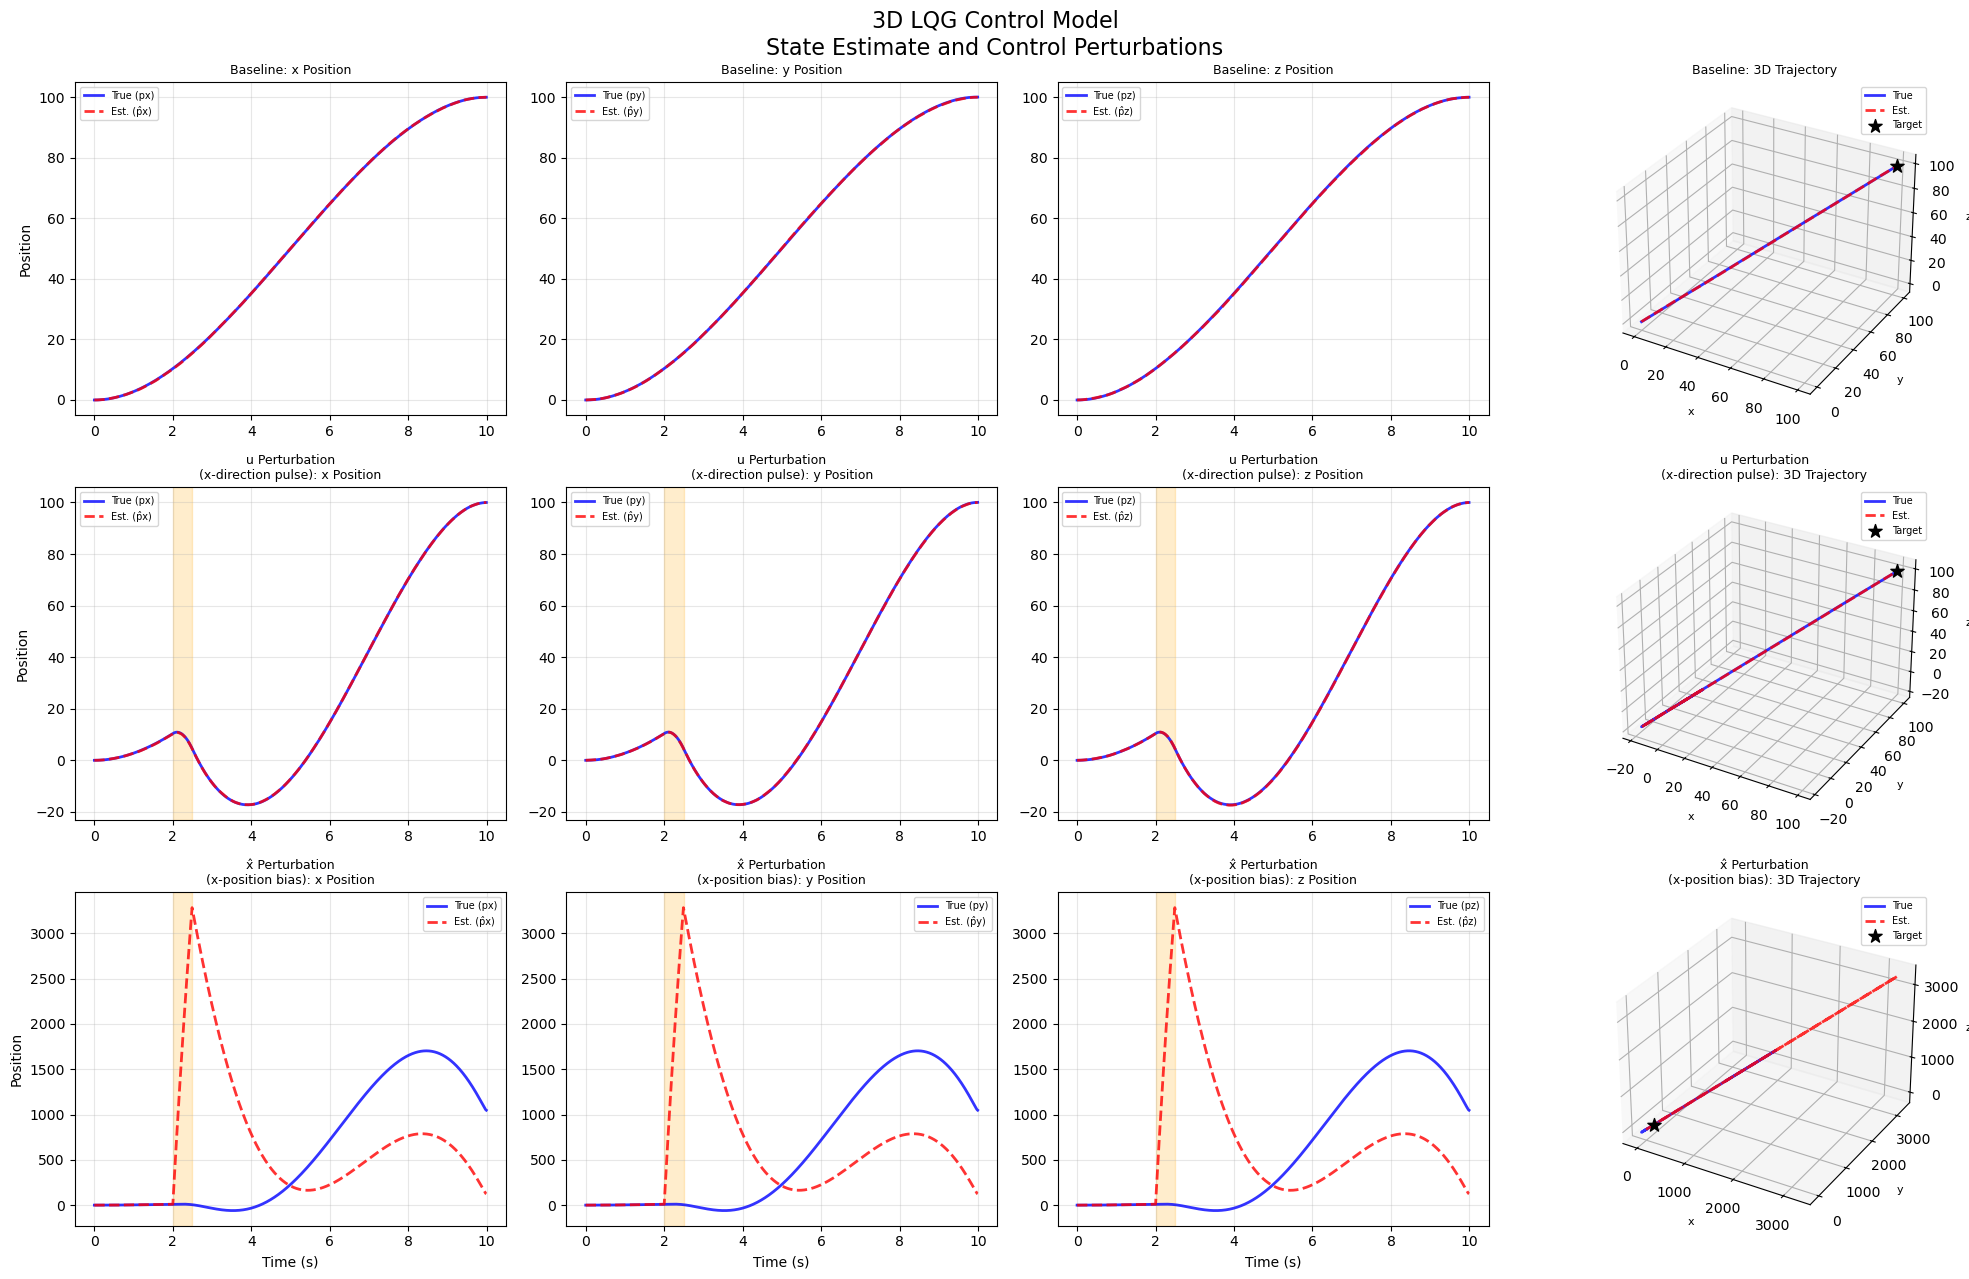

In [7]:
from mpl_toolkits.mplot3d import Axes3D

time = np.arange(horizon) * dt
span_kw = dict(alpha=0.2, color='orange')

fig = plt.figure(figsize=(20, 13))
fig.suptitle('3D LQG Control Model\nState Estimate and Control Perturbations', fontsize=16, y=0.98)

row_labels = ['Baseline', 'u Perturbation\n(x-direction pulse)', 'x̂ Perturbation\n(x-position bias)']

# data for each row: (px_true, py_true, pz_true, px_est, py_est, pz_est, pert_span)
rows = [
    (px_baseline,    py_baseline,    pz_baseline,    pxhat_baseline,    pyhat_baseline,    pzhat_baseline,    None),
    (px_u_pert,      py_u_pert,      pz_u_pert,      pxhat_u_pert,      pyhat_u_pert,      pzhat_u_pert,      (perturbation_start, perturbation_end)),
    (px_xhat_pert,   py_xhat_pert,   pz_xhat_pert,   pxhat_xhat_pert,   pyhat_xhat_pert,   pzhat_xhat_pert,   (perturbation_start, xhat_pulse_end)),
]

col_titles = ['x Position', 'y Position', 'z Position', '3D Trajectory']

# store 2D position axes for y-limit normalization
pos_axes = [[None] * 3 for _ in range(3)]

for row_idx, (px, py, pz, pxhat, pyhat, pzhat, span) in enumerate(rows):
    # x position
    ax = fig.add_subplot(3, 4, row_idx * 4 + 1)
    pos_axes[row_idx][0] = ax
    ax.plot(time, px,    'b-',  lw=2, label='True (px)',  alpha=0.8)
    ax.plot(time, pxhat, 'r--', lw=2, label='Est. (p̂x)', alpha=0.8)
    if span:
        ax.axvspan(span[0] * dt, span[1] * dt, **span_kw)
    ax.set_ylabel('Position', fontsize=10)
    ax.set_title(f'{row_labels[row_idx]}: {col_titles[0]}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if row_idx == 2:
        ax.set_xlabel('Time (s)', fontsize=10)

    # y position
    ax = fig.add_subplot(3, 4, row_idx * 4 + 2)
    pos_axes[row_idx][1] = ax
    ax.plot(time, py,    'b-',  lw=2, label='True (py)',  alpha=0.8)
    ax.plot(time, pyhat, 'r--', lw=2, label='Est. (p̂y)', alpha=0.8)
    if span:
        ax.axvspan(span[0] * dt, span[1] * dt, **span_kw)
    ax.set_title(f'{row_labels[row_idx]}: {col_titles[1]}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if row_idx == 2:
        ax.set_xlabel('Time (s)', fontsize=10)

    # z position
    ax = fig.add_subplot(3, 4, row_idx * 4 + 3)
    pos_axes[row_idx][2] = ax
    ax.plot(time, pz,    'b-',  lw=2, label='True (pz)',  alpha=0.8)
    ax.plot(time, pzhat, 'r--', lw=2, label='Est. (p̂z)', alpha=0.8)
    if span:
        ax.axvspan(span[0] * dt, span[1] * dt, **span_kw)
    ax.set_title(f'{row_labels[row_idx]}: {col_titles[2]}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if row_idx == 2:
        ax.set_xlabel('Time (s)', fontsize=10)

    # 3D trajectory
    ax3d = fig.add_subplot(3, 4, row_idx * 4 + 4, projection='3d')
    ax3d.plot(px,    py,    pz,    'b-',  lw=2, label='True',   alpha=0.8)
    ax3d.plot(pxhat, pyhat, pzhat, 'r--', lw=2, label='Est.',   alpha=0.8)
    ax3d.scatter([T_px], [T_py], [T_pz], c='k', marker='*', s=100, label='Target')
    ax3d.set_xlabel('x', fontsize=8)
    ax3d.set_ylabel('y', fontsize=8)
    ax3d.set_zlabel('z', fontsize=8)
    ax3d.set_title(f'{row_labels[row_idx]}: {col_titles[3]}', fontsize=9)
    ax3d.legend(fontsize=7)

# normalize y-axis per row: each row gets its own scale so perturbation effects are clear within that row
_row_pos_data = [
    np.concatenate([px_baseline,  pxhat_baseline,  py_baseline,  pyhat_baseline,  pz_baseline,  pzhat_baseline]),
    np.concatenate([px_u_pert,    pxhat_u_pert,    py_u_pert,    pyhat_u_pert,    pz_u_pert,    pzhat_u_pert]),
    np.concatenate([px_xhat_pert, pxhat_xhat_pert, py_xhat_pert, pyhat_xhat_pert, pz_xhat_pert, pzhat_xhat_pert]),
]
for row_idx, data in enumerate(_row_pos_data):
    _pad = (data.max() - data.min()) * 0.05
    for col_idx in range(3):
        pos_axes[row_idx][col_idx].set_ylim(data.min() - _pad, data.max() + _pad)

plt.tight_layout()
plt.show()

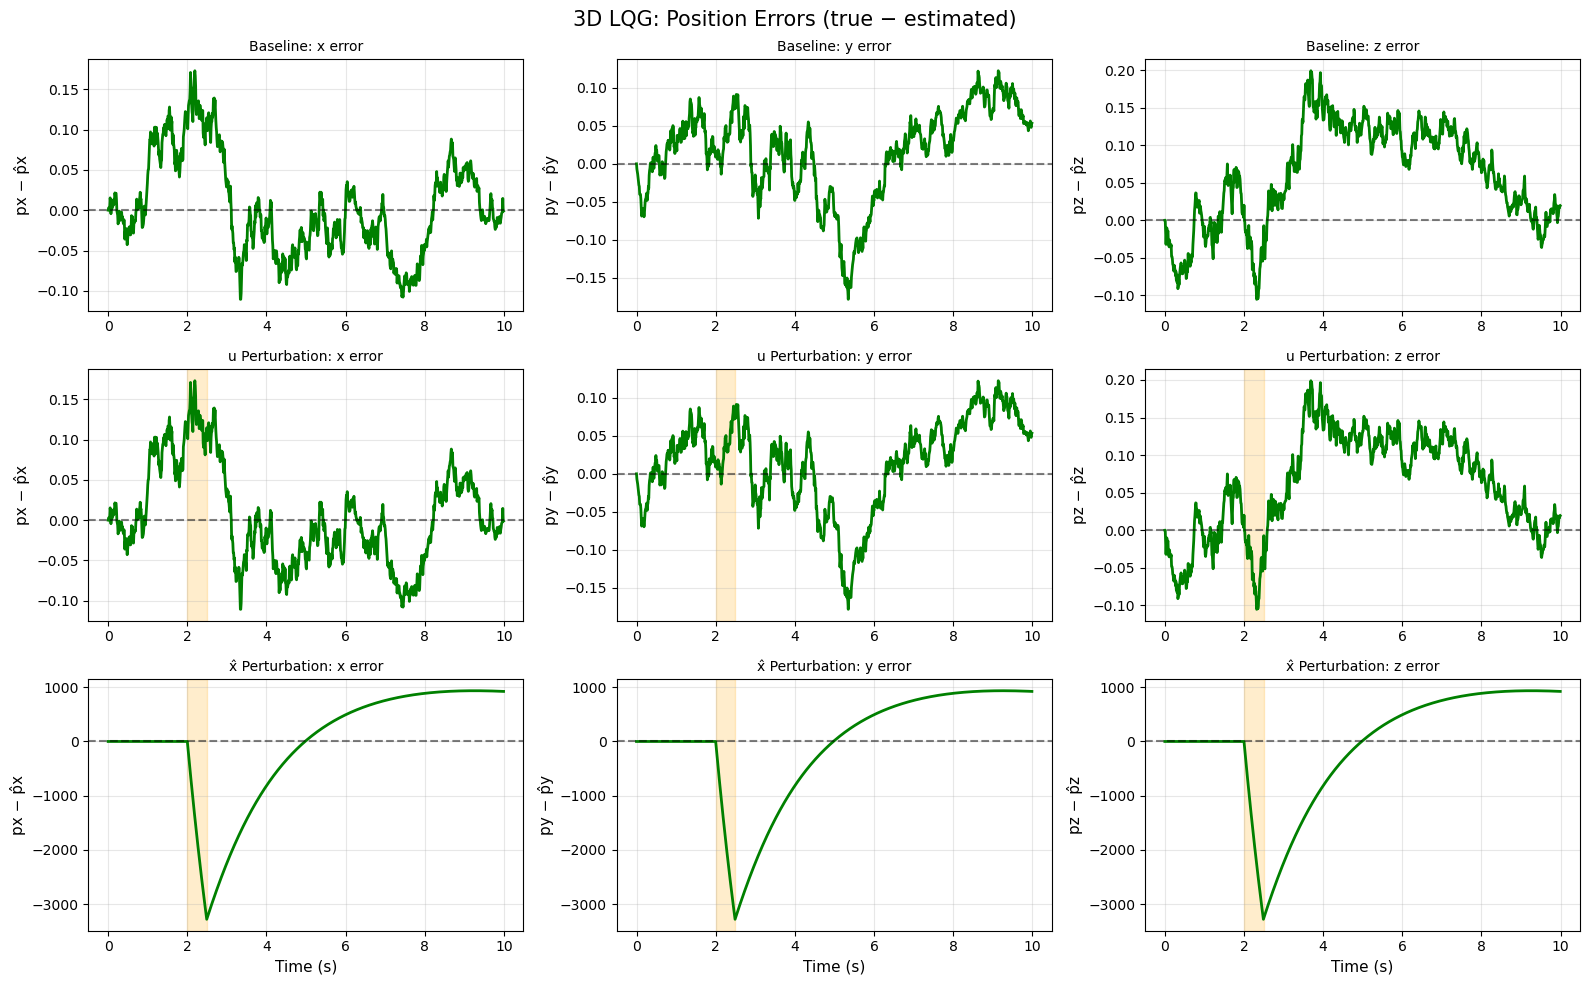

In [8]:
# error plots: px - p̂x, py - p̂y, pz - p̂z for all three conditions
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('3D LQG: Position Errors (true − estimated)', fontsize=15, y=0.98)

error_baseline_x = px_baseline - pxhat_baseline
error_baseline_y = py_baseline - pyhat_baseline
error_baseline_z = pz_baseline - pzhat_baseline

row_data = [
    (error_baseline_x, error_baseline_y, error_baseline_z, 'Baseline', None),
    (error_x_u,        error_y_u,        error_z_u,        'u Perturbation', (perturbation_start, perturbation_end)),
    (error_x_xhat,     error_y_xhat,     error_z_xhat,     'x̂ Perturbation', (perturbation_start, xhat_pulse_end)),
]

col_ylabels = ['px − p̂x', 'py − p̂y', 'pz − p̂z']
col_titles_err = ['x error', 'y error', 'z error']

for row_idx, (ex, ey, ez, label, span) in enumerate(row_data):
    for col_idx, (err, ylabel, ctitle) in enumerate(zip([ex, ey, ez], col_ylabels, col_titles_err)):
        ax = axes[row_idx, col_idx]
        ax.plot(time, err, 'g-', lw=2)
        ax.axhline(0, color='k', ls='--', alpha=0.5)
        if span:
            ax.axvspan(span[0] * dt, span[1] * dt, **span_kw)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{label}: {ctitle}', fontsize=10)
        ax.grid(True, alpha=0.3)
        if row_idx == 2:
            ax.set_xlabel('Time (s)', fontsize=11)

plt.tight_layout()
plt.show()